In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedGroupKFold

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.base import clone

In [2]:
DATA_PATH = "../../data/pr_review_traces/processed/final_security_patch.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5000, 29)


,repo_name,pr_number,pr_title,pr_body,pr_state,pr_created_at,pr_updated_at,pr_merged_at,pr_merge_commit_sha,pr_additions,...,line,original_line,side,start_line,original_start_line,author_association,comment_created_at,comment_updated_at,security_label,label_notes
0,grommet/hpe-design-system,5159,add datafilters wcag,<!--- Provide a general summary of the PR in t...,closed,2025-05-13T05:06:52Z,2025-05-20T00:28:06Z,2025-05-20T00:28:06Z,ed2105adad46b12a9272c15d35f3aaee6a47026b,1040,...,NaN,6,RIGHT,NaN,NaN,COLLABORATOR,2025-05-15T18:22:15Z,2025-05-15T18:22:15Z,0,No security-relevant topic found in the commen...
1,appsmithorg/appsmith,39646,feat: implement table widget infinite scroll w...,## Description\r\nThis PR adds support for var...,closed,2025-03-10T08:00:48Z,2025-03-21T10:14:18Z,2025-03-20T09:23:37Z,c162311f43efe652627cdf1b950d7eb7419043e8,594,...,NaN,55,RIGHT,NaN,38.0,CONTRIBUTOR,2025-03-19T05:22:40Z,2025-03-19T05:28:15Z,1,Labeled 1: comment/diff references a security-...
2,adorsys/status-list-server,55,feat: add keypair generation to startup logic,NaN,closed,2025-04-24T12:13:50Z,2025-05-23T09:31:36Z,2025-05-23T09:31:33Z,35084ed00253b0d082124e96014502a4f340667b,351,...,NaN,99,RIGHT,NaN,NaN,COLLABORATOR,2025-05-05T15:48:29Z,2025-05-05T16:15:35Z,1,Labeled 1: comment/diff contains a clear secur...
3,vinteumorg/Floresta,402,Re-structured functional tests.,Improves https://github.com/vinteumorg/Florest...,closed,2025-03-07T14:34:25Z,2025-03-12T16:19:02Z,2025-03-12T16:19:02Z,443bf8defd0b7a370d267e6253ec2d4291a496bb,447,...,330.0,330,RIGHT,NaN,NaN,MEMBER,2025-03-10T15:48:21Z,2025-03-10T15:48:21Z,1,Labeled 1: comment/diff contains a clear secur...
4,vacanza/holidays,2502,Update India holidays: add missing Tamil Nadu ...,<!--\r\n Thanks for contributing to holidays!...,closed,2025-04-26T14:04:29Z,2025-05-05T18:10:53Z,2025-04-28T20:20:40Z,5f154404cac9bee763b2cbafa2e9e15ef993741c,155,...,905.0,905,RIGHT,869.0,869.0,CONTRIBUTOR,2025-04-26T16:36:43Z,2025-04-26T16:36:44Z,0,No security-relevant topic found in the commen...


In [3]:
print("Columns:")
for column in df.columns:
    print("-", column)

Columns:
- repo_name
- pr_number
- pr_title
- pr_body
- pr_state
- pr_created_at
- pr_updated_at
- pr_merged_at
- pr_merge_commit_sha
- pr_additions
- pr_deletions
- pr_changed_files
- comment_id
- review_id
- review_comment
- diff_hunk
- file_path
- commit_id
- original_commit_id
- line
- original_line
- side
- start_line
- original_start_line
- author_association
- comment_created_at
- comment_updated_at
- security_label
- label_notes


In [4]:
print("Security label distribution:")
print(df["security_label"].value_counts().sort_index())

Security label distribution:
security_label
0    2930
1    1073
2     997
Name: count, dtype: int64


In [5]:
df_binary = df[df["security_label"].isin([0, 1])].copy()

df_binary["security_label"] = df_binary["security_label"].astype(int)

print("Binary dataset shape:", df_binary.shape)
print("\nBinary label distribution:")
print(df_binary["security_label"].value_counts().sort_index())

Binary dataset shape: (4003, 29)

Binary label distribution:
security_label
0    2930
1    1073
Name: count, dtype: int64


In [6]:
print("Missing review comments:", df_binary["review_comment"].isna().sum())
print("Missing repository names:", df_binary["repo_name"].isna().sum())
print("Missing PR numbers:", df_binary["pr_number"].isna().sum())

Missing review comments: 0
Missing repository names: 0
Missing PR numbers: 0


In [7]:
def clean_comment(text):
    if pd.isna(text):
        return ""
    
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


df_binary["comment_text"] = df_binary["review_comment"].apply(clean_comment)

print(df_binary["comment_text"].head())

0    Let's fix to give more detail and then after i...
1    Why do we have multiple ifs? you can improve t...
2    You don't need to explicitly rely on the std l...
3    i agree with davidson, a `uv run tests/run_tes...
4    _🧹 Nitpick (assertive)_ **Consider adding a so...
Name: comment_text, dtype: str


In [8]:
df_binary["pr_group"] = (
    df_binary["repo_name"].astype(str)
    + "#"
    + df_binary["pr_number"].astype(str)
)

print("Unique PR groups:", df_binary["pr_group"].nunique())

Unique PR groups: 2762


In [9]:
X = df_binary["comment_text"]
y = df_binary["security_label"]
groups = df_binary["pr_group"]

print("Number of samples:", len(X))
print("Number of groups:", groups.nunique())
print("Class distribution:")
print(y.value_counts().sort_index())

Number of samples: 4003
Number of groups: 2762
Class distribution:
security_label
0    2930
1    1073
Name: count, dtype: int64


In [10]:
tfidf_params = {
    "lowercase": True,
    "stop_words": "english",
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,
    "sublinear_tf": True
}

print(tfidf_params)

{'lowercase': True, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.95, 'sublinear_tf': True}


In [11]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),
    
    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        max_features="sqrt"
    )
}

In [12]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [13]:
def calculate_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }

In [14]:
fold_results = []
oof_predictions = []

for model_name, model in models.items():
    
    print(f"\nRunning: {model_name}")
    
    for fold, (train_idx, val_idx) in enumerate(
        cv.split(X, y, groups),
        start=1
    ):
        
        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]
        
        # Fit TF-IDF only on training data
        vectorizer = TfidfVectorizer(**tfidf_params)
        
        X_train_tfidf = vectorizer.fit_transform(X_train)
        X_val_tfidf = vectorizer.transform(X_val)
        
        # Train model
        clf = clone(model)
        clf.fit(X_train_tfidf, y_train)
        
        # Predict validation fold
        y_pred = clf.predict(X_val_tfidf)
        
        # Metrics
        metrics = calculate_metrics(y_val, y_pred)
        
        fold_results.append({
            "model": model_name,
            "fold": fold,
            "train_samples": len(train_idx),
            "validation_samples": len(val_idx),
            "train_groups": groups.iloc[train_idx].nunique(),
            "validation_groups": groups.iloc[val_idx].nunique(),
            **metrics
        })
        
        # Store out-of-fold predictions
        fold_predictions = df_binary.iloc[val_idx][
            [
                "repo_name",
                "pr_number",
                "comment_id",
                "review_comment",
                "diff_hunk",
                "file_path",
                "security_label"
            ]
        ].copy()
        
        fold_predictions["model"] = model_name
        fold_predictions["fold"] = fold
        fold_predictions["prediction"] = y_pred
        
        oof_predictions.append(fold_predictions)
        
        print(
            f"  Fold {fold}: "
            f"Accuracy={metrics['accuracy']:.4f}, "
            f"Balanced Accuracy={metrics['balanced_accuracy']:.4f}, "
            f"F1={metrics['f1']:.4f}"
        )


Running: Logistic Regression
  Fold 1: Accuracy=0.6488, Balanced Accuracy=0.5725, F1=0.3843
  Fold 2: Accuracy=0.6587, Balanced Accuracy=0.5668, F1=0.3666
  Fold 3: Accuracy=0.6562, Balanced Accuracy=0.5770, F1=0.3875
  Fold 4: Accuracy=0.6338, Balanced Accuracy=0.5513, F1=0.3532
  Fold 5: Accuracy=0.6713, Balanced Accuracy=0.5649, F1=0.3538

Running: Linear SVM
  Fold 1: Accuracy=0.6687, Balanced Accuracy=0.5832, F1=0.3927
  Fold 2: Accuracy=0.6425, Balanced Accuracy=0.5528, F1=0.3500
  Fold 3: Accuracy=0.6462, Balanced Accuracy=0.5524, F1=0.3464
  Fold 4: Accuracy=0.6350, Balanced Accuracy=0.5447, F1=0.3394
  Fold 5: Accuracy=0.6500, Balanced Accuracy=0.5489, F1=0.3365

Running: Random Forest
  Fold 1: Accuracy=0.7011, Balanced Accuracy=0.5922, F1=0.3909
  Fold 2: Accuracy=0.6925, Balanced Accuracy=0.5587, F1=0.3204
  Fold 3: Accuracy=0.7063, Balanced Accuracy=0.5755, F1=0.3490
  Fold 4: Accuracy=0.6813, Balanced Accuracy=0.5540, F1=0.3200
  Fold 5: Accuracy=0.6800, Balanced Accurac

In [15]:
fold_metrics = pd.DataFrame(fold_results)

fold_metrics

,model,fold,train_samples,validation_samples,train_groups,validation_groups,accuracy,balanced_accuracy,precision,recall,f1
0,Logistic Regression,1,3200,803,2204,558,0.648817,0.572528,0.363636,0.407407,0.384279
1,Logistic Regression,2,3203,800,2223,539,0.658750,0.566832,0.364055,0.369159,0.366589
2,Logistic Regression,3,3203,800,2201,561,0.656250,0.576991,0.370213,0.406542,0.387528
3,Logistic Regression,4,3203,800,2201,561,0.633750,0.551250,0.334728,0.373832,0.353201
4,Logistic Regression,5,3203,800,2219,543,0.671250,0.564878,0.375000,0.334884,0.353808
5,Linear SVM,1,3200,803,2204,558,0.668742,0.583231,0.387387,0.398148,0.392694
6,Linear SVM,2,3203,800,2223,539,0.642500,0.552773,0.340708,0.359813,0.350000
7,Linear SVM,3,3203,800,2201,561,0.646250,0.552367,0.342466,0.350467,0.346420
8,Linear SVM,4,3203,800,2201,561,0.635000,0.544688,0.328947,0.350467,0.339367
9,Linear SVM,5,3203,800,2219,543,0.650000,0.548877,0.342995,0.330233,0.336493


In [16]:
cv_summary = (
    fold_metrics
    .groupby("model")
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std")
    )
    .reset_index()
)

cv_summary

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Linear SVM,0.648498,0.012603,0.556387,0.015355,0.348501,0.022483,0.357826,0.024998,0.352995,0.022838
1,Logistic Regression,0.653763,0.013801,0.566496,0.009769,0.361526,0.015700,0.378365,0.030139,0.369081,0.016301
2,Random Forest,0.692224,0.011681,0.562911,0.022051,0.394773,0.036203,0.284176,0.049546,0.329781,0.044808


In [17]:
cv_summary_rounded = cv_summary.copy()

metric_columns = [
    "accuracy_mean",
    "accuracy_std",
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "precision_mean",
    "precision_std",
    "recall_mean",
    "recall_std",
    "f1_mean",
    "f1_std"
]

cv_summary_rounded[metric_columns] = (
    cv_summary_rounded[metric_columns]
    .round(4)
)

cv_summary_rounded

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Linear SVM,0.6485,0.0126,0.5564,0.0154,0.3485,0.0225,0.3578,0.0250,0.3530,0.0228
1,Logistic Regression,0.6538,0.0138,0.5665,0.0098,0.3615,0.0157,0.3784,0.0301,0.3691,0.0163
2,Random Forest,0.6922,0.0117,0.5629,0.0221,0.3948,0.0362,0.2842,0.0495,0.3298,0.0448


In [18]:
oof_df = pd.concat(
    oof_predictions,
    ignore_index=True
)

print("OOF prediction rows:", len(oof_df))
print(
    oof_df.groupby("model").size()
)

OOF prediction rows: 12009
model
Linear SVM             4003
Logistic Regression    4003
Random Forest          4003
dtype: int64


In [19]:
OUTPUT_DIR = "patch_ml_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

oof_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "comment_only_oof_predictions.csv"
    ),
    index=False
)

fold_metrics.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "comment_only_fold_metrics.csv"
    ),
    index=False
)

cv_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "comment_only_cv_summary.csv"
    ),
    index=False
)

print("Results saved.")

Results saved.


In [20]:
confusion_results = {}

for model_name in models.keys():
    
    model_oof = oof_df[
        oof_df["model"] == model_name
    ]
    
    cm = confusion_matrix(
        model_oof["security_label"],
        model_oof["prediction"],
        labels=[0, 1]
    )
    
    confusion_results[model_name] = cm
    
    print(f"\n{model_name}")
    print(cm)


Logistic Regression
[[2211  719]
 [ 667  406]]

Linear SVM
[[2212  718]
 [ 689  384]]

Random Forest
[[2466  464]
 [ 768  305]]


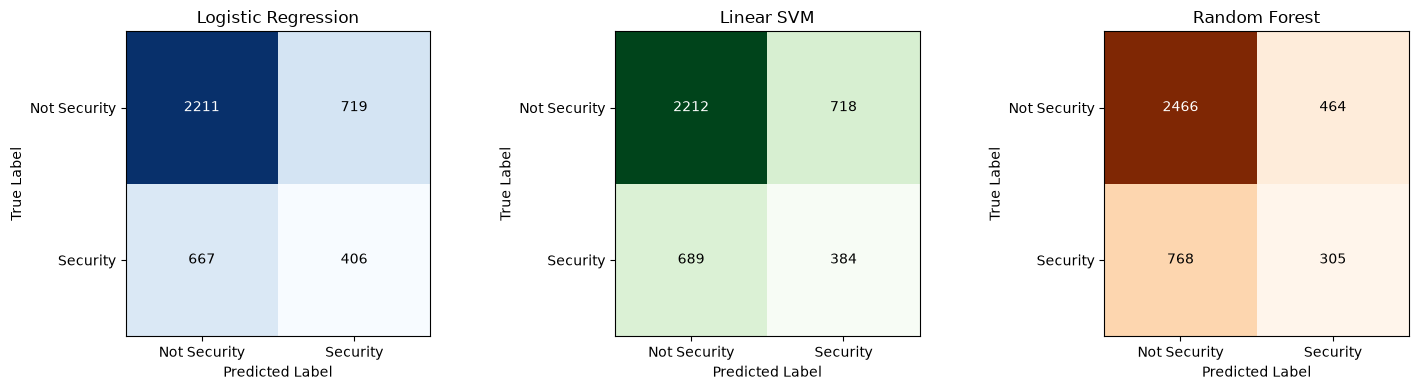

In [21]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

cmaps = ["Blues", "Greens", "Oranges"]

for ax, (model_name, cm), cmap in zip(
    axes,
    confusion_results.items(),
    cmaps
):
    ax.imshow(cm, cmap=cmap)

    ax.set_title(model_name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["Not Security", "Security"])
    ax.set_yticklabels(["Not Security", "Security"])

    threshold = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black"
            )

plt.tight_layout()
plt.show()


In [22]:
error_cases = []

for model_name in models.keys():
    
    model_oof = oof_df[
        oof_df["model"] == model_name
    ].copy()
    
    model_oof["error_type"] = "Correct"
    
    model_oof.loc[
        (model_oof["security_label"] == 0) &
        (model_oof["prediction"] == 1),
        "error_type"
    ] = "False Positive"
    
    model_oof.loc[
        (model_oof["security_label"] == 1) &
        (model_oof["prediction"] == 0),
        "error_type"
    ] = "False Negative"
    
    errors = model_oof[
        model_oof["error_type"] != "Correct"
    ].copy()
    
    error_cases.append(errors)

error_cases_df = pd.concat(
    error_cases,
    ignore_index=True
)

print(
    error_cases_df["error_type"].value_counts()
)

error_type
False Negative    2124
False Positive    1901
Name: count, dtype: int64


In [23]:
false_positives = error_cases_df[
    error_cases_df["error_type"] == "False Positive"
].copy()

print("False positives:", len(false_positives))

false_positives[
    [
        "model",
        "repo_name",
        "pr_number",
        "comment_id",
        "review_comment",
        "diff_hunk",
        "file_path",
        "security_label",
        "prediction"
    ]
].head(20)

False positives: 1901


,model,repo_name,pr_number,comment_id,review_comment,diff_hunk,file_path,security_label,prediction
2,Logistic Regression,econia-labs/emojicoin-dot-fun,707,1999453186,```suggestion\r\n NormalCandlestick: (d) => D...,"@@ -66,6 +69,7 @@ export const brokerMessageCo...",src/typescript/sdk/src/broker-v2/types.ts,0,1
5,Logistic Regression,christianhelle/sqlitequery,78,2075651798,[nitpick] Since multiple package formats are g...,"@@ -24,16 +24,36 @@ jobs:\n - name: Update...",.github/workflows/linux.yml,0,1
7,Logistic Regression,zyfra/Prizm,2437,2014132179,это специально убрали?,"@@ -17,7 +17,6 @@\n ""cypress:open"": ""cypre...",package.json,0,1
9,Logistic Regression,epicollect5/epicollect5-server,10,1984866964,_🧹 Nitpick (assertive)_\n\n**Updated Docblock ...,"@@ -31,7 +32,7 @@ public function __construct(...",app/Http/Controllers/Api/Entries/View/ViewEntr...,0,1
12,Logistic Regression,cognitedata/dotnet-simulator-utils,239,1975028429,"agreed, removed this from here","@@ -0,0 +1,226 @@\n+using System;\n+using Syst...",Cognite.Simulator.Utils/LicenseController.cs,0,1
13,Logistic Regression,dosbox-staging/dosbox-staging,4245,2008412307,`contains()` from `support.h`?,"@@ -772,16 +772,33 @@ void filter_compatible_s...",src/hardware/vga_s3.cpp,0,1
15,Logistic Regression,Alpine-DAV/ascent,1478,1999638469,"I'll have a few style suggestions :-), if you ...","@@ -5271,302 +5260,333 @@ VTKHParticleAdvectio...",src/libs/ascent/runtimes/flow_filters/ascent_r...,0,1
20,Logistic Regression,llvm/llvm-project,139816,2094602873,"Added a test for this in `pattern.mlir`, also ...","@@ -1883,6 +1888,9 @@ def : Pat<(TestEitherOpA...",mlir/test/lib/Dialect/Test/TestOps.td,0,1
22,Logistic Regression,FoundatioFx/Foundatio.Redis,101,2090070034,Using -1 as a fallback for the Redis database ...,"@@ -35,15 +36,19 @@ public RedisCacheClient(Re...",src/Foundatio.Redis/Cache/RedisCacheClient.cs,0,1
26,Logistic Regression,dm94/stiletto-web,242,2094628237,**suggestion (testing):** Consider more descri...,"@@ -521,13 +521,15 @@ const MemberList = () =>...",src/pages/MemberList.tsx,0,1


In [24]:
false_negatives = error_cases_df[
    error_cases_df["error_type"] == "False Negative"
].copy()

print("False negatives:", len(false_negatives))

false_negatives[
    [
        "model",
        "repo_name",
        "pr_number",
        "comment_id",
        "review_comment",
        "diff_hunk",
        "file_path",
        "security_label",
        "prediction"
    ]
].head(20)

False negatives: 2124


,model,repo_name,pr_number,comment_id,review_comment,diff_hunk,file_path,security_label,prediction
0,Logistic Regression,adorsys/status-list-server,55,2073701034,You don't need to explicitly rely on the std l...,"@@ -72,18 +74,37 @@ impl Keypair {\n pub f...",src/utils/keygen.rs,1,0
1,Logistic Regression,vinteumorg/Floresta,402,1987570671,"i agree with davidson, a `uv run tests/run_tes...","@@ -258,53 +258,64 @@ cargo test --release\n \...",README.md,1,0
3,Logistic Regression,apache/gravitino,6599,1997862708,"Yes , all the items in values.yaml can be cus...","@@ -0,0 +1,208 @@\n+#\n+# Licensed to the Apac...",dev/charts/gravitino/values.yaml,1,0
4,Logistic Regression,openshift/openshift-docs,89396,1985680689,done,"@@ -0,0 +1,116 @@\n+// Module included in the ...",modules/ossm-migrating-workloads-using-the-ist...,1,0
6,Logistic Regression,causify-ai/helpers,374,1999651519,Are 39-46 still needed then?\r\n\r\nLet's try ...,"@@ -48,8 +50,9 @@ jobs:\n id: login-ec...",.github/workflows/fast_tests.yml,1,0
8,Logistic Regression,opendatahub-io/opendatahub-tests,175,1999354657,`if _upgrade_deployment_modes` -> need to retu...,"@@ -102,19 +123,45 @@ def pytest_collection_mo...",conftest.py,1,0
10,Logistic Regression,i-am-bee/beeai-framework,583,2002188488,Updated for tests.,"@@ -0,0 +1,55 @@\n+# Copyright 2025 IBM Corp.\...",python/tests/tools/test_python.py,1,0
11,Logistic Regression,AI-Hypercomputer/maxtext,1310,2033767600,Can you include some comments about this logic...,"@@ -0,0 +1,444 @@\n+""""""\n+Copyright 2025 Googl...",MaxText/elastic_train.py,1,0
14,Logistic Regression,bcgov/lear,3523,2116877801,Thanks! Was just running into this starting to...,"@@ -24,3 +23,14 @@ git+https://github.com/bcgo...",queue_services/entity-digital-credentials/requ...,1,0
16,Logistic Regression,make-all/tuya-local,3017,1986426112,Name should be human readable,"@@ -0,0 +1,312 @@\n+name: Keypad lock\n+produc...",custom_components/tuya_local/devices/hornbill_...,1,0


In [25]:
error_cases_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "comment_only_false_positive_false_negative_cases.csv"
    ),
    index=False
)

print("Error cases saved.")

Error cases saved.


In [26]:
for model_name in models.keys():
    
    model_oof = oof_df[
        oof_df["model"] == model_name
    ]
    
    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    
    print(
        classification_report(
            model_oof["security_label"],
            model_oof["prediction"],
            target_names=[
                "Not Security",
                "Security"
            ],
            digits=4,
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

Not Security     0.7682    0.7546    0.7614      2930
    Security     0.3609    0.3784    0.3694      1073

    accuracy                         0.6538      4003
   macro avg     0.5646    0.5665    0.5654      4003
weighted avg     0.6591    0.6538    0.6563      4003


Linear SVM
              precision    recall  f1-score   support

Not Security     0.7625    0.7549    0.7587      2930
    Security     0.3485    0.3579    0.3531      1073

    accuracy                         0.6485      4003
   macro avg     0.5555    0.5564    0.5559      4003
weighted avg     0.6515    0.6485    0.6500      4003


Random Forest
              precision    recall  f1-score   support

Not Security     0.7625    0.8416    0.8001      2930
    Security     0.3966    0.2842    0.3312      1073

    accuracy                         0.6922      4003
   macro avg     0.5796    0.5629    0.5656      4003
weighted avg     0.6644   